In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
data_set = pd.read_csv("../data/Divar.csv")
data_set.shape

C:\Users\sepeh\AppData\Local\Temp\ipykernel_11188\2929480387.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  data_set = pd.read_csv("../data/Divar.csv")


(1000000, 61)

In [3]:
data_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

### A :

In [4]:
print("Cat2_Slug : \n\n", data_set["cat2_slug"].unique())
print("\nCat3_Slug : \n\n", data_set["cat3_slug"].unique())

Cat2_Slug : 

 <StringArray>
[      'temporary-rent',     'residential-sell',     'residential-rent',
      'commercial-rent',      'commercial-sell', 'real-estate-services']
Length: 6, dtype: str

Cat3_Slug : 

 <StringArray>
[                             'villa',                     'apartment-sell',
                     'apartment-rent',                        'office-rent',
                          'shop-sell',                           'plot-old',
                   'house-villa-sell',                   'house-villa-rent',
                          'shop-rent', 'industry-agriculture-business-rent',
                        'office-sell', 'industry-agriculture-business-sell',
                            'presell',                    'suite-apartment',
                        'partnership',                          'workspace',
                                  nan]
Length: 17, dtype: str


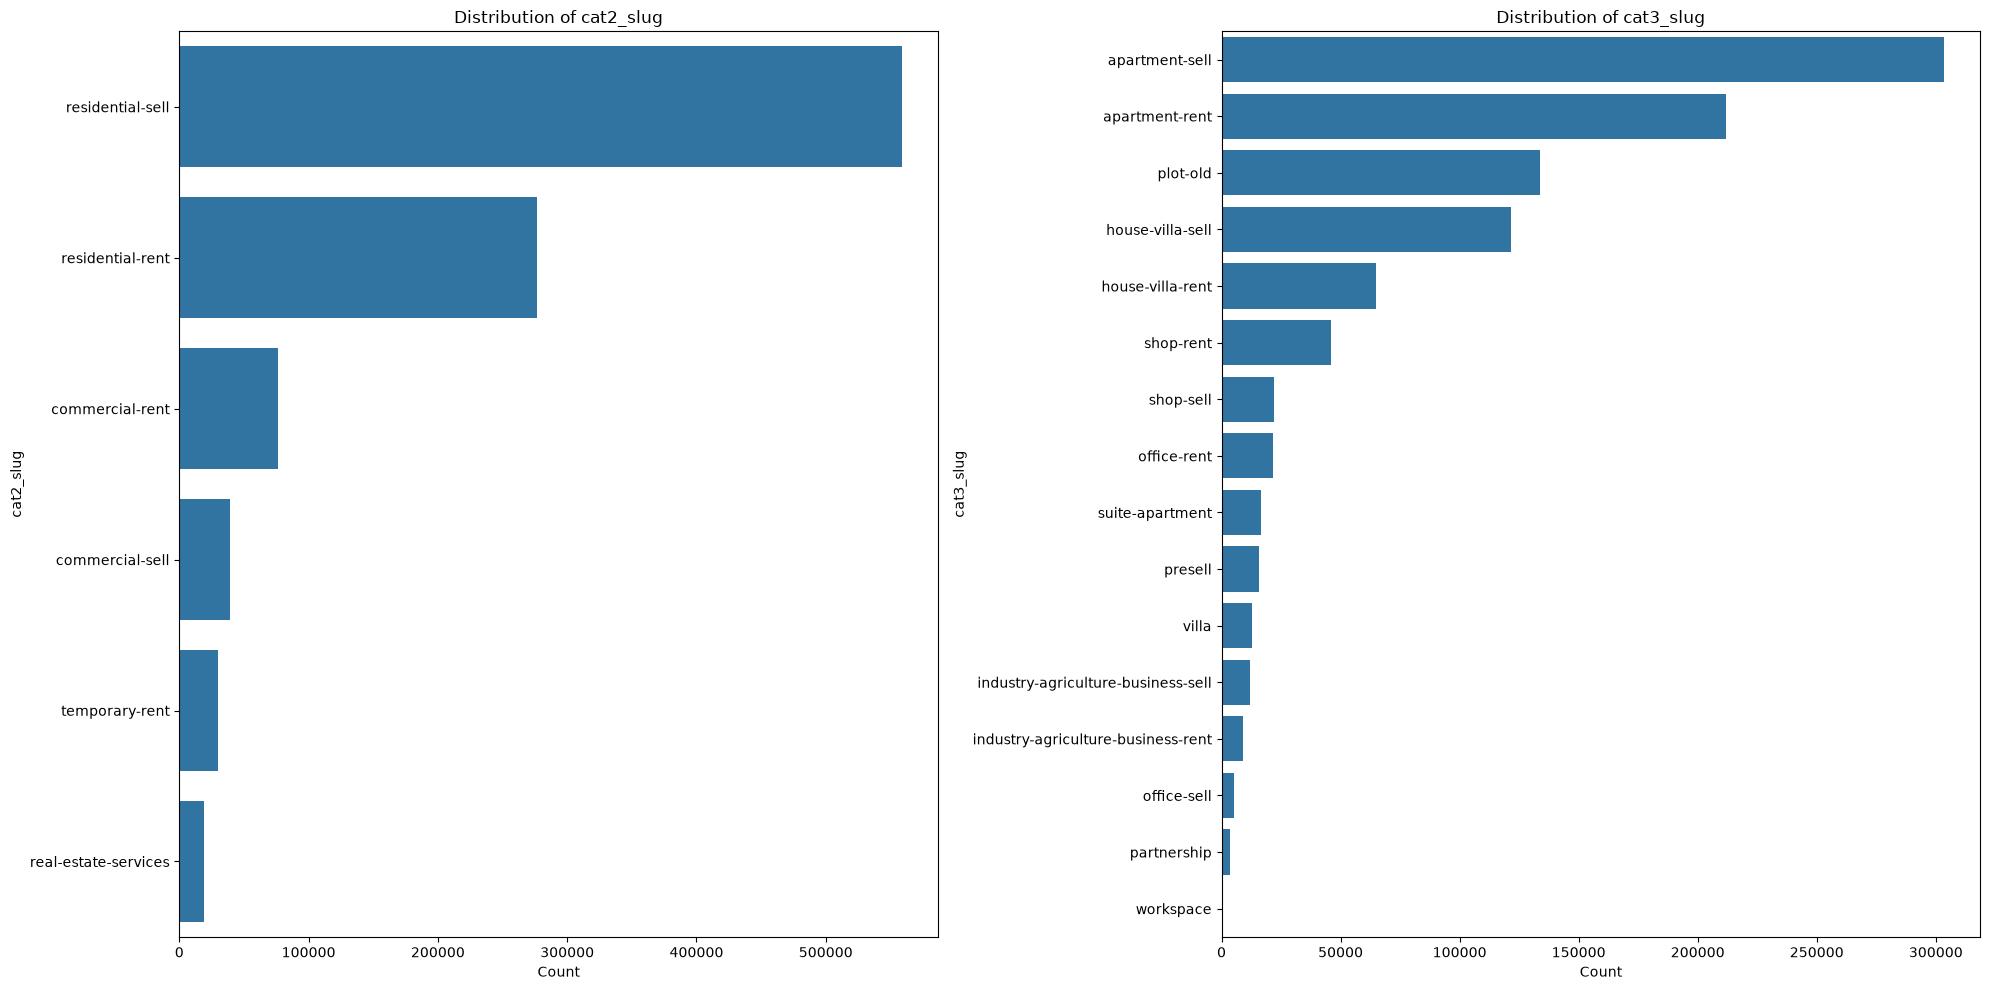

In [5]:
#main task :
cat2_order = data_set["cat2_slug"].value_counts().index
cat3_order = data_set["cat3_slug"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(data=data_set, y="cat2_slug", order=cat2_order, ax=axes[0])
axes[0].set(title="Distribution of cat2_slug", xlabel="Count", ylabel="cat2_slug")

sns.countplot(data=data_set, y="cat3_slug", order=cat3_order, ax=axes[1])
axes[1].set(title="Distribution of cat3_slug", xlabel="Count", ylabel="cat3_slug")

plt.tight_layout()
plt.show()

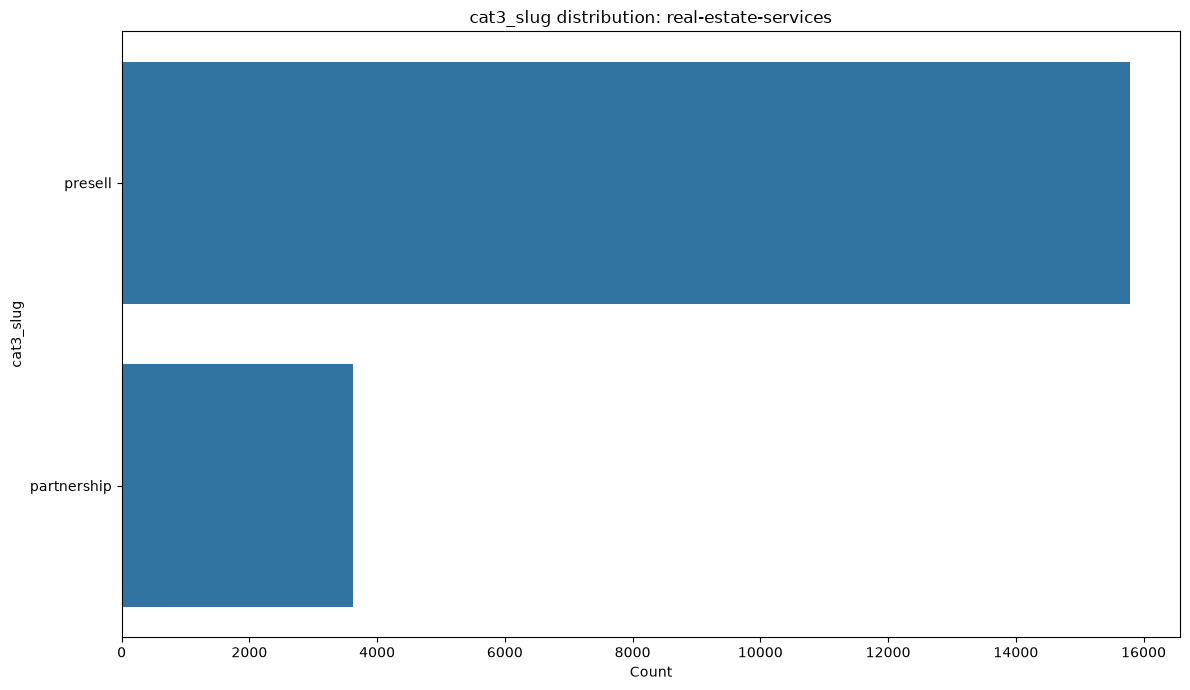

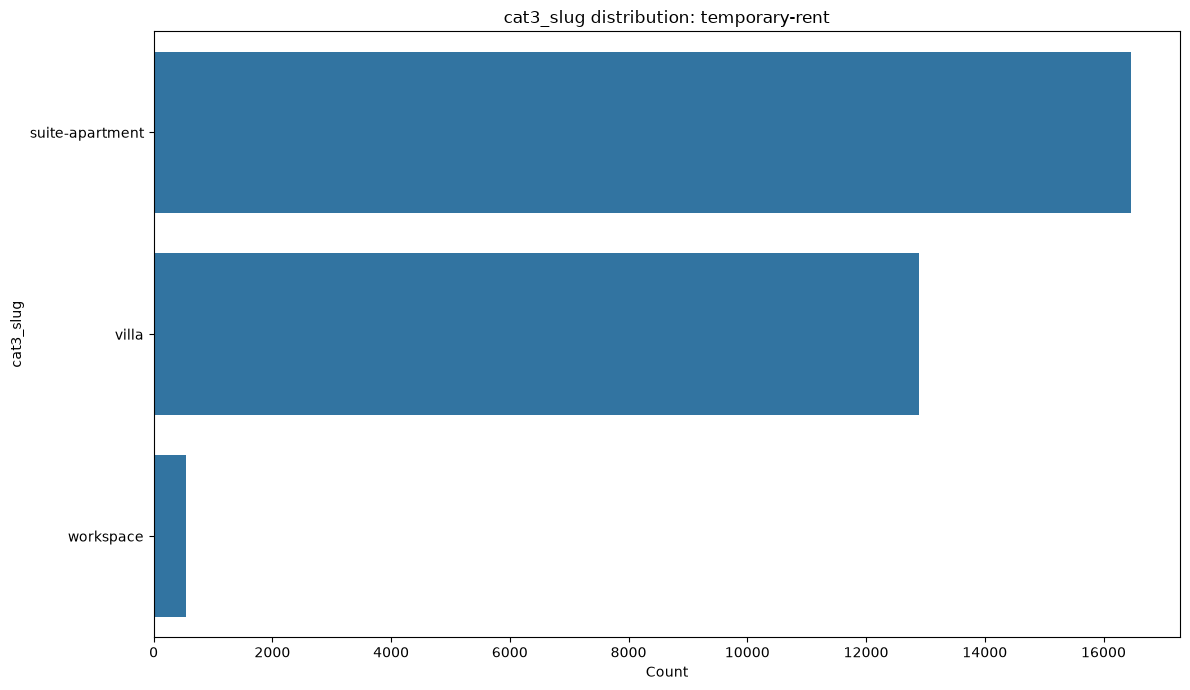

In [6]:
# cat3_slug distribution for real-estate-services (non-zero categories only)
real_estate_services = data_set.loc[
    data_set["cat2_slug"].eq("real-estate-services"), "cat3_slug"
].dropna()
real_estate_order = real_estate_services.value_counts().index

plt.figure(figsize=(12, 7))
sns.countplot(y=real_estate_services, order=real_estate_order)
plt.title("cat3_slug distribution: real-estate-services")
plt.xlabel("Count")
plt.ylabel("cat3_slug")
plt.tight_layout()
plt.show()

# cat3_slug distribution for temporary-rent (non-zero categories only)
temporary_rent = data_set.loc[
    data_set["cat2_slug"].eq("temporary-rent"), "cat3_slug"
].dropna()
temporary_rent_order = temporary_rent.value_counts().index

plt.figure(figsize=(12, 7))
sns.countplot(y=temporary_rent, order=temporary_rent_order)
plt.title("cat3_slug distribution: temporary-rent")
plt.xlabel("Count")
plt.ylabel("cat3_slug")
plt.tight_layout()
plt.show()

In [7]:
print("cat3_slug == plot_old : \n",
      data_set[data_set["cat3_slug"]== "plot-old"]["cat2_slug"].unique().tolist())
print("\n\ncat3_slug == suite_apartment : \n"
      ,data_set[data_set["cat3_slug"] == "suite-apartment"]["cat2_slug"].unique().tolist())
print("\n\ncat3_slug == presell : \n"
      ,data_set[data_set["cat3_slug"] == "presell"]["cat2_slug"].unique().tolist())

cat3_slug == plot_old : 
 ['residential-sell']


cat3_slug == suite_apartment : 
 ['temporary-rent']


cat3_slug == presell : 
 ['real-estate-services']


### D:

In [8]:
print("rent_mode unique values : \n",
      data_set["rent_mode"].unique().tolist()) # مجانی یعنی چییی اخه

print("\n\nrent_type unique values : \n",
      data_set["rent_type"].unique().tolist())

rent_mode unique values : 
 [nan, 'مقطوع', 'مجانی', 'توافقی']


rent_type unique values : 
 [nan, 'rent_credit', 'full_credit']


In [9]:
price_columns = [
    "rent_mode",
    "rent_value",
    "rent_type",
    "price_mode",
    "price_value",
    "credit_mode",
    "credit_value"
]

for column in price_columns:
    
    print(f"\n{'=' * 50}")
    print(column)
    
    if data_set[column].dtype in ["str", "object"]:
        print("unique values:")
        print(data_set[column].dropna().unique().tolist())
        
    else:
        print(
            data_set[column].agg(
                ["min", "mean", "median", "max"]
            )
        )
        
        #5_000_000
        #2_400_000_000 ->be nazaram ke price ha be Toman hast.


rent_mode
unique values:
['مقطوع', 'مجانی', 'توافقی']

rent_value
min       0.000000e+00
mean      4.102299e+10
median    5.000000e+06
max       1.000000e+15
Name: rent_value, dtype: float64

rent_type
unique values:
['rent_credit', 'full_credit']

price_mode
unique values:
['مقطوع', 'مجانی', 'توافقی']

price_value
min       0.000000e+00
mean      1.736537e+10
median    2.840000e+09
max       1.000000e+14
Name: price_value, dtype: float64

credit_mode
unique values:
['مقطوع', 'مجانی', 'توافقی']

credit_value
min       0.000000e+00
mean      4.872084e+10
median    2.500000e+08
max       1.000000e+15
Name: credit_value, dtype: float64


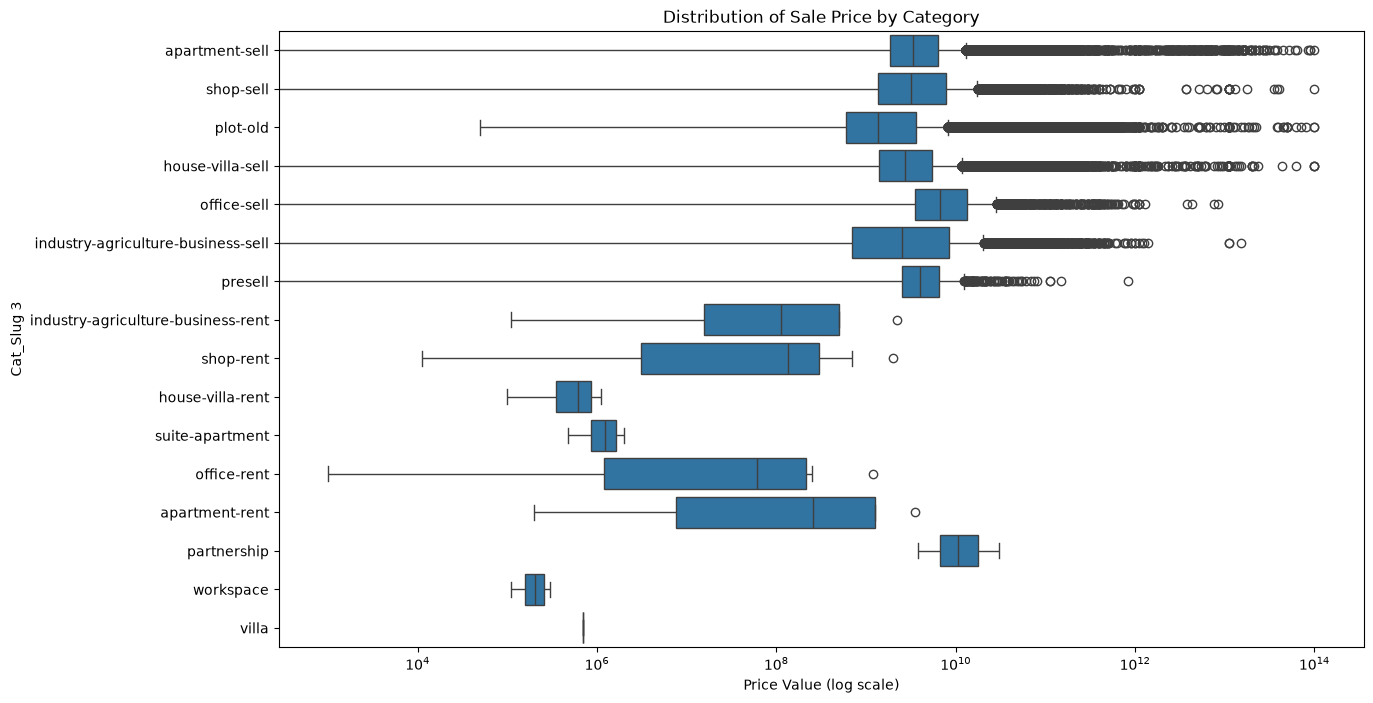

In [10]:
price_data = data_set[
    ["cat3_slug", "price_value"]
].dropna()

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=price_data,
    y="cat3_slug",
    x="price_value"
    )

plt.xscale("log")

plt.title("Distribution of Sale Price by Category")
plt.xlabel("Price Value (log scale)")
plt.ylabel("Cat_Slug 3")

plt.show()

In [11]:
price_summary = (
    data_set
    .groupby("cat3_slug")["price_value"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("count", ascending=False)
)

print(price_summary)


                                     count          mean        median  \
cat3_slug                                                                
apartment-sell                      303380  1.549611e+10  3.300000e+09   
house-villa-sell                    121748  1.538754e+10  2.700000e+09   
plot-old                            109836  2.243806e+10  1.350000e+09   
shop-sell                            18559  2.912003e+10  3.200000e+09   
industry-agriculture-business-sell    9088  1.853477e+10  2.500000e+09   
office-sell                           4480  2.530203e+10  6.750000e+09   
presell                               1204  6.718369e+09  4.000000e+09   
shop-rent                               23  2.658700e+08  1.350000e+08   
partnership                              6  1.340185e+10  1.055556e+10   
office-rent                              6  2.616006e+08  6.090000e+07   
industry-agriculture-business-rent       5  5.653444e+08  1.111111e+08   
apartment-rent                        